### Training script BERT 

Why BERT? 
LLMs are overkill for this problem. 
BERT is more efficient. 
Based on huggingface tutorial. 

### Import necessary packages & load data 

In [1]:
from datasets import load_from_disk
import datasets 
from transformers import AutoTokenizer 
import sys
sys.path.append("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu")
from data.CyberMetric import CyberMetric_evaluator
from openai import OpenAI 
import re
import evaluate
import numpy as np
import torch 
#!pip install nlpaug
from transformers import Trainer 
from torch import nn 
num_classes = 9

KAs = {"0": "miscellaneous (this includes Computer Science, Business and Law, Communication and Networking, Information Technology, Cyberspace Practice, Pedagogy, and Intelligence)",
           "1": "data security", 
           "2": "software security",
           "3": "component security", 
           "4": "connection security", 
           "5": "system security", 
           "6": "human security", 
           "7": "organizational security",
           "8": "societal security"}

/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


### Load functions

In [10]:
from sklearn.utils.class_weight import compute_class_weight 
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
from sklearn.model_selection import StratifiedKFold, KFold
from transformers import set_seed 
import copy
set_seed(42)

def clean_text(text): 
    special_chars = r'[\"\[\]\',]'
    cleaned_text = re.sub(special_chars, '', text)
    # replace - or _ with space 
    special_chars = r'[\_\-]'
    cleaned_text2 = re.sub(special_chars,' ', cleaned_text)
    return cleaned_text2 

clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])

def sigmoid(x):
   return 1/(1 + np.exp(-x))

def compute_metrics(eval_pred):
   predictions, labels = eval_pred
   predictions = sigmoid(predictions)
   predictions = (predictions > 0.5).astype(int).reshape(-1)
   return clf_metrics.compute(predictions=predictions, references=labels.astype(int).reshape(-1))

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')  
# to create a batch of examples. This dynamically pads the text to the lenght of the longest element in the batch. 
def preprocess(example):
        # preprocess and tokenize data 
        text = f"{example['Statement Description']}"       # our text to be labeled is the description of the KD
        text = text[13:]                                   # remove "Knowledge of" since it's the same for every KD
        text = clean_text(text)                            # remove special characters
        one_hot = list(example.values())[1:9]              # read one-hot encoding 
        example = tokenizer(text)                          # tokenize text 
        example['labels'] = torch.tensor(one_hot).float()
        return example 

#### 
from sklearn.preprocessing import LabelEncoder 
def get_new_labels(y): 
    y_new = LabelEncoder().fit_transform([''.join(str(l)) for l in y])
    return y_new 

dataset = datasets.load_dataset("csv",data_files={"train": "data/train_data.csv"}, split='train')
dataset = dataset.remove_columns('KSAT ID')
dataset = dataset.map(preprocess)
print(dataset)

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 576
})


In [11]:
print(dataset['labels'])

[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0], [0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0], [0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0], [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0], [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

In [14]:
# CSEC2017 specific! 
dataset = datasets.load_dataset("csv",data_files={"train": "data/train_CSEC2017.csv"}, split='train')
dataset = dataset.remove_columns('Statement Description')
dataset = dataset.remove_columns('label')
#dataset = dataset.remove_columns('6')
#dataset = dataset.remove_columns('7')
#dataset = dataset.remove_columns('8')
print(dataset)

def preprocess_csec(example):
        # preprocess and tokenize data 
        text = f"{example['topics']}"       # our text to be labeled is the description of the KD
        text = text[13:]                                   # remove "Knowledge of" since it's the same for every KD
        text = clean_text(text)                            # remove special characters
        one_hot = list(example.values())[1:9]              # read one-hot encoding 
        #one_hot = [int(x) for x in one_hot]
        example = tokenizer(text)                          # tokenize text 
        example['labels'] = torch.tensor(one_hot).float()
        return example 

#data = dataset.map(preprocess_csec)
#print(data)
#print(data['labels'])

Dataset({
    features: ['Unnamed: 0', 'topics', '1', '2', '3', '4', '5', '6', '7', '8', 'Unnamed: 12'],
    num_rows: 1650
})


In [15]:
# oversampling 
#!pip install pytorch-multilabel-balanced-sampler
from pytorch_multilabel_balanced_sampler.samplers import RandomClassSampler, ClassCycleSampler, LeastSampledClassSampler 

def balance_dataset(dataset): 
    n_samples = 9*205
    sampler = LeastSampledClassSampler(labels=torch.tensor(dataset['labels']).to(torch.long))
    labels = []
    samples = []
    for sample in sampler: 
        labels.append(dataset['labels'][sample])
        samples.append(sample)
    
    balanced_ds = dataset.select(samples)
    return balanced_ds
    
# Data augmentation module 
import nlpaug.augmenter.word as naw 
import random 

def data_augmentation(example, rs=True, ri=True, swap=True, de=True): 
    #text = example['Statement Description']
    text = f"{example['Statement Description']}"       # our text to be labeled is the description of the KD
    text = text[13:]                                   # remove "Knowledge of" since it's the same for every KD
    text = clean_text(text) 
    before = text 
    augmentations = [] 
    augmentations.append('none')
    if ri == True: 
        augmentations.append('insertion')
    if rs == True: 
        augmentations.append('substitution')
    if swap == True: 
        augmentations.append('swap')
    if de == True: 
        augmentations.append('delete') 
    selected_augmentations = random.choices(augmentations, weights=[0.6, 0.1, 0.1, 0.1, 0.1]) 
    # insert some words in the sentence 
    if 'insertion' in selected_augmentations: 
        aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="insert")
        text = aug.augment(text)
    # replace word with a synonym 
    if 'substitution' in selected_augmentations: 
        aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="substitute")
        text = aug.augment(text)
    # swap word randomly
    if 'swap' in selected_augmentations: 
        aug = naw.RandomWordAug(action="swap") 
        text = aug.augment(text)
    # delete word randomly 
    if 'delete' in selected_augmentations: 
        aug = naw.RandomWordAug()
        text = aug.augment(text)
    if 'none' not in selected_augmentations: 
        #print('before: ',before)
        #print('augmentation: ', text[0])
        example['Statement Description'] = clean_text(text[0])
        example = tokenizer(text[0]) 
        #print(example)
    return example

text = 'The quick brown fox jumps over the lazy dog' 
print(text)
#print(data_augmentation(text))

The quick brown fox jumps over the lazy dog


### Train model 

In [30]:
import datasets 
import pandas as pd
from datasets import Dataset 
from datasets import concatenate_datasets 
from sklearn.metrics import multilabel_confusion_matrix
datasets.disable_caching()
class Transformer:
    def __init__(self, datapath, class_weights=False, model_name='distilbert-base-uncased',num_classes=9, k_folds=5, device=None): 
        self.num_classes = num_classes
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu") 
        self.model_name = model_name 
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)             # the tokenizer is the same for all folds 
        self.data_collator = DataCollatorWithPadding(tokenizer=self.tokenizer) # the data collator is the same for all folds 
        self.load_data(datapath)                                               # we can load and tokenize the data already 
        self.k_folds = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)  # Stratified k-folds is not for multi-label problems
        self.class_weights = class_weights                                     # whether we weight the loss with class weights or not 
        
    def init_models(self, model_name): 
        # dropout = 02 (attention dropuot?) 
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                                        problem_type="multi_label_classification",
                                                                        num_labels=self.num_classes, dropout=0.2)
    def load_data(self, datapath): 
        dataset = datasets.load_dataset("csv",data_files={"train": "data/train_data.csv"}, split='train')
        dataset = dataset.remove_columns('KSAT ID')
        #dataset = datasets.load_dataset("csv",data_files={"train": "data/train_CSEC2017.csv"}, split='train')
        #dataset = dataset.remove_columns('Statement Description')
        #dataset = dataset.remove_columns('label')
        self.data = dataset.map(preprocess)
        # create labels for stratified k split 
        self.y_new = get_new_labels(self.data['labels'])

    def train(self, training_args, data_aug=False, balance=False, synthetic=False): 
        fold_results = [] 
        self.dict1 = {}
        self.dict2 = {}
        for fold, (train_idx, val_idx) in enumerate(self.k_folds.split(self.data, self.y_new)): 
            print(f"Training on fold {fold + 1}")
            self.train_dataset = copy.deepcopy(self.data.select(train_idx.tolist()))
            val_dataset = copy.deepcopy(self.data.select(val_idx.tolist()))
            self.val_dataset = copy.deepcopy(val_dataset)
            self.init_models(self.model_name)                    # we must re-initiate the classification model for every fold
            # this is where we would add the synthetic data
            self.train_dataset = self.train_dataset.remove_columns(['Statement Description', '0'])
            if synthetic == True: 
                dataset = datasets.load_dataset("csv",data_files={"train": "data/train_CSEC2017.csv"}, split='train')
                dataset = dataset.remove_columns('Statement Description')
                dataset = dataset.remove_columns('label')
                dataset = dataset.remove_columns(['Unnamed: 0','Unnamed: 12'])
                dataset = dataset.map(preprocess_csec) 
                dataset = dataset.remove_columns(['topics'])
                
                train_dataset = self.train_dataset.remove_columns(['Statement Description', '0'])
                # merge train_dataset KDs with CSEC dataset  
                self.train_dataset = concatenate_datasets([train_dataset, dataset])
                print(self.train_dataset)

            if data_aug == True: 
                #print('true')
                output = self.train_dataset.map(data_augmentation)
                self.train_dataset = copy.deepcopy(output)

            if balance == True: 
                self.train_dataset = balance_dataset(copy.deepcopy(self.train_dataset))
            
            self.trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=self.train_dataset,
            eval_dataset=self.val_dataset,
            tokenizer=self.tokenizer,
            data_collator=self.data_collator,
            compute_metrics=compute_metrics,)
          
            self.trainer.train()
            metrics = self.trainer.evaluate()
            print(f"Fold {fold+1} results_before: {metrics}")
            output = self.trainer.predict(self.val_dataset)
            self.dict1[fold] = copy.deepcopy(output[1])
            self.dict2[fold] = copy.deepcopy(output[0])
                
            predictions = sigmoid(output[0])
            predictions = (predictions > 0.5).astype(int) #.reshape(-1)
            self.conf_matrix = multilabel_confusion_matrix(output[1].astype(int), predictions)
            print('confusion matrix: ',self.conf_matrix)
            fold_results.append(metrics)
            print(f"Fold {fold+1} results: {metrics}")
            
        avg_metrics = {key: np.mean([fold[key] for fold in fold_results]) for key in fold_results[0]}
        print(f"Average metrics across all folds: {avg_metrics}")
        return avg_metrics

datapath = "data/train_data.csv"
trans2 = Transformer(datapath, k_folds=5, num_classes=8) 
#print(trans.data)
training_args = TrainingArguments(
        output_dir="DistilBERTv1",
        learning_rate=5e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=20,
        weight_decay=0.01,
        logging_steps=100,
        # I added these three 
        eval_strategy="epoch",
       # save_strategy="epoch",
       # load_best_model_at_end=True,
       # metric_for_best_model='f1',
       # save_total_limit=1,
    )
#print(trans.val_dataset)
trans2.train(training_args, balance=False, data_aug=False, synthetic=False)

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/local/tmp.3575543/ipykernel_1857239/3388648279.py:66: FutureWarning: `tokenizer` is d

Training on fold 1


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.286512,0.906250,0.000000,0.000000,0.000000
2,No log,0.268382,0.906250,0.000000,0.000000,0.000000
3,No log,0.257631,0.906250,0.000000,0.000000,0.000000
4,0.306300,0.232441,0.923491,0.432000,0.710526,0.310345
5,0.306300,0.222178,0.922414,0.409836,0.714286,0.287356
6,0.306300,0.225208,0.921336,0.459259,0.645833,0.356322
7,0.192000,0.229332,0.922414,0.437500,0.682927,0.321839
8,0.192000,0.228389,0.919181,0.482759,0.603448,0.402299
9,0.192000,0.235705,0.924569,0.507042,0.654545,0.413793
10,0.192000,0.244012,0.922414,0.513514,0.622951,0.436782


/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le

...

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/local/tmp.3575543/ipykernel_1857239/3388648279.py:66: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  self.trainer = Trainer(
Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.284748,0.907609,0.000000,0.000000,0.000000
2,No log,0.266970,0.907609,0.000000,0.000000,0.000000
3,No log,0.250557,0.907609,0.000000,0.000000,0.000000
4,0.308100,0.243128,0.907609,0.330709,0.500000,0.247059
5,0.308100,0.245856,0.907609,0.429530,0.500000,0.376471
6,0.308100,0.233273,0.914130,0.455172,0.550000,0.388235
7,0.183500,0.231622,0.915217,0.458333,0.559322,0.388235
8,0.183500,0.233716,0.918478,0.452555,0.596154,0.364706
9,0.183500,0.234984,0.916304,0.437956,0.576923,0.352941
10,0.183500,0.247114,0.916304,0.490066,0.560606,0.435294


/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le

Fold 5 results_before: {'eval_loss': 0.28264060616493225, 'eval_accuracy': 0.9195652173913044, 'eval_f1': 0.486111111111111, 'eval_precision': 0.5932203389830508, 'eval_recall': 0.4117647058823529, 'eval_runtime': 0.0899, 'eval_samples_per_second': 1278.995, 'eval_steps_per_second': 88.974, 'epoch': 20.0}
confusion matrix:  [[[103   0]
  [  8   4]]

 [[110   0]
  [  4   1]]

 [[112   0]
  [  2   1]]

 [[ 93   7]
  [  7   8]]

 [[104   1]
  [  7   3]]

 [[114   0]
  [  1   0]]

 [[ 66  14]
  [ 18  17]]

 [[109   2]
  [  3   1]]]
Fold 5 results: {'eval_loss': 0.28264060616493225, 'eval_accuracy': 0.9195652173913044, 'eval_f1': 0.486111111111111, 'eval_precision': 0.5932203389830508, 'eval_recall': 0.4117647058823529, 'eval_runtime': 0.0899, 'eval_samples_per_second': 1278.995, 'eval_steps_per_second': 88.974, 'epoch': 20.0}
Average metrics across all folds: {'eval_loss': 0.2791021943092346, 'eval_accuracy': 0.9183883058470764, 'eval_f1': 0.5216301680175819, 'eval_precision': 0.5731156370

{'eval_loss': 0.2791021943092346,
 'eval_accuracy': 0.9183883058470764,
 'eval_f1': 0.5216301680175819,
 'eval_precision': 0.5731156370757207,
 'eval_recall': 0.48159127381737904,
 'eval_runtime': 0.09226,
 'eval_samples_per_second': 1252.5610000000001,
 'eval_steps_per_second': 86.9768,
 'epoch': 20.0}

### Analyses

In [11]:
labels = np.concatenate([np.array(v) for v in trans.dict1.values()])
print(labels)
predictions = np.concatenate([np.array(v) for v in trans.dict2.values()])
#print(predictions)
pred0 = sigmoid(predictions)
pred0 = (pred0 > 0.5).astype(int).reshape(-1)
metrics1 = clf_metrics.compute(predictions=pred0, references=labels.astype(int).reshape(-1))
print(metrics1)
opt_thresholds = find_optimal_thresholds(labels,predictions)
print('opt_thresholds: ', opt_thresholds)
predictions = (sigmoid(predictions) >= np.array([opt_thresholds[i] for i in range(9)]))
predictions = np.array(predictions, dtype=np.int32)
metrics2 = clf_metrics.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1))
print(metrics2)
conf_matrix = multilabel_confusion_matrix(labels.astype(int), predictions)

[[0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 0.]]
{'accuracy': 0.9085648148148148, 'f1': 0.5948717948717949, 'precision': 0.6456400742115028, 'recall': 0.5515055467511886}
opt_thresholds:  {0: 0.48131672, 1: 0.5170397, 2: 0.2521078, 3: 0.21018179, 4: 0.25989673, 5: 0.3044688, 6: 0.1, 7: 0.53754467, 8: 0.123646036}
{'accuracy': 0.90625, 'f1': 0.6029411764705883, 'precision': 0.6222596964586846, 'recall': 0.5847860538827259}


In [ ]:
labels = np.concatenate([np.array(v) for v in trans2.dict1.values()])
print(labels)
predictions = np.concatenate([np.array(v) for v in trans2.dict2.values()])
#print(predictions)
pred0 = sigmoid(predictions)
pred0 = (pred0 > 0.5).astype(int).reshape(-1)
metrics1 = clf_metrics.compute(predictions=pred0, references=labels.astype(int).reshape(-1))
print(metrics1)
opt_thresholds = find_optimal_thresholds(labels,predictions)
print('opt_thresholds: ', opt_thresholds)
predictions = (sigmoid(predictions) >= np.array([opt_thresholds[i] for i in range(9)]))
predictions = np.array(predictions, dtype=np.int32)
metrics2 = clf_metrics.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1))
print(metrics2)
conf_matrix = multilabel_confusion_matrix(labels.astype(int), predictions)

[3337 3171  742  266  489 2148  507 1282  200]


Text(0.5, 1.0, 'label distribution synthetic LLM-labelled')

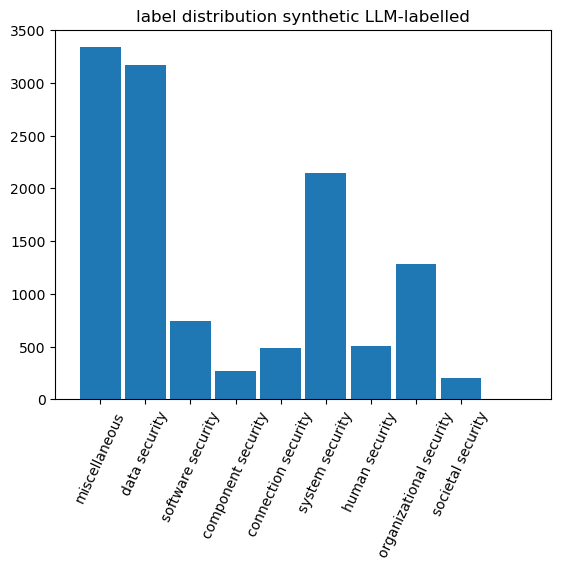

In [31]:
# check labels 
import matplotlib.pyplot as plt 
from collections import Counter 
dataset = copy.deepcopy(dataset2)
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in dataset['labels']], axis=0)
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
counts = np.bincount(non_oh)
print(counts)

x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security"]
# plot histogram of labels 
fig, ax = plt.subplots();
ax.bar(range(9), counts, width=0.9, align='center');
ax.set(xticks=range(9), xlim=[-1,10]);
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=65)
ax.set_title('label distribution synthetic LLM-labelled')

In [5]:
import matplotlib.pyplot as plt 
from collections import Counter 
dataset = copy.deepcopy(trans.data)
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in dataset['labels']], axis=0)
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
counts = np.bincount(non_oh)
print(counts)

x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security"]
# plot histogram of labels 
fig, ax = plt.subplots();
ax.bar(range(9), counts, width=0.9, align='center');
ax.set(xticks=range(9), xlim=[-1,10]);
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=65)
ax.set_title('label distribution 2017 KDs')


Bad key text.latex.preview in file /mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 123 ('text.latex.preview : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.7.3/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file /mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 155 ('mathtext.fallback_to_cm : True  # When True, use symbols from the Computer Modern')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.7.3/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key savefig.jpeg_quality in file /mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/ma

NameError: name 'trans' is not defined

### Evaluation

In [23]:
labels = np.concatenate([np.array(v) for v in trans.dict1.values()])
print(labels)
predictions = np.concatenate([np.array(v) for v in trans.dict2.values()])
#print(predictions)
pred0 = sigmoid(predictions)
pred0 = (pred0 > 0.5).astype(int).reshape(-1)
metrics1 = clf_metrics.compute(predictions=pred0, references=labels.astype(int).reshape(-1))
print(metrics1)
#opt_thresholds = find_optimal_thresholds(labels,predictions)
#print('opt_thresholds: ', opt_thresholds)
predictions = (sigmoid(predictions) >= 0.5) #np.array([opt_thresholds[i] for i in range(9)]))
predictions = np.array(predictions, dtype=np.int32)
metrics2 = clf_metrics.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1))
print(metrics2)
conf_matrix = multilabel_confusion_matrix(labels.astype(int), predictions)

[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]
{'accuracy': 0.919921875, 'f1': 0.5450061652281134, 'precision': 0.574025974025974, 'recall': 0.5187793427230047}
{'accuracy': 0.919921875, 'f1': 0.5450061652281134, 'precision': 0.574025974025974, 'recall': 0.5187793427230047}


In [ ]:
labels = np.concatenate([np.array(v) for v in trans2.dict1.values()])
print(labels)
predictions = np.concatenate([np.array(v) for v in trans2.dict2.values()])
#print(predictions)
pred0 = sigmoid(predictions)
pred0 = (pred0 > 0.5).astype(int).reshape(-1)
metrics1 = clf_metrics.compute(predictions=pred0, references=labels.astype(int).reshape(-1))
print(metrics1)
#opt_thresholds = find_optimal_thresholds(labels,predictions)
#print('opt_thresholds: ', opt_thresholds)
predictions = (sigmoid(predictions) >= 0.5) #np.array([opt_thresholds[i] for i in range(9)]))
predictions = np.array(predictions, dtype=np.int32)
metrics2 = clf_metrics.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1))
print(metrics2)
conf_matrix = multilabel_confusion_matrix(labels.astype(int), predictions)

In [ ]:
import matplotlib.pyplot as plt 
# turn this into a column plot. 
print(conf_matrix)
TP = conf_matrix[:,1,1]
print(TP)
FP = conf_matrix[:,0,1]
FN = conf_matrix[:,1,0]
print(FP)
print(FN)

# plot 
x_labels = ["data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security"]
#x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
#            "system security", "human security",  "organizational security","societal security"]
x = np.arange(len(x_labels))

width = 0.3 
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(x-width, TP, width,label='TP', color='tab:green')
ax.bar(x, FP, width, label= 'FP', color='tab:red')
ax.bar(x + width, FN, width, label='FN', color='tab:blue')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylabel('number of samples')
ax.set_title('10-fold cross validation TP/FP/FN')
ax.legend()

[[[519   4]
  [ 34  19]]

 [[543   7]
  [ 17   9]]

 [[558   2]
  [ 14   2]]

 [[465  31]
  [ 30  50]]

 [[518   6]
  [ 46   6]]

 [[567   4]
  [  5   0]]

 [[300 100]
  [ 48 128]]

 [[548  10]
  [ 11   7]]]
[ 19   9   2  50   6   0 128   7]
[  4   7   2  31   6   4 100  10]
[34 17 14 30 46  5 48 11]


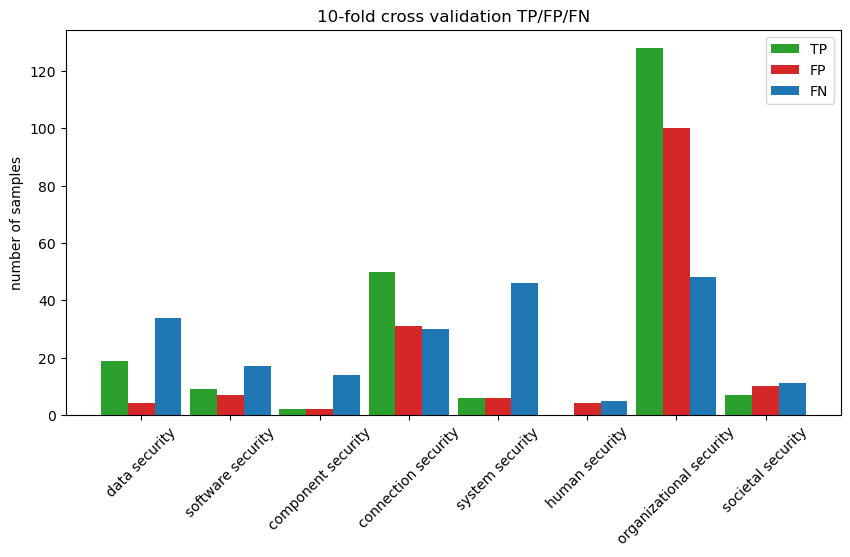

In [27]:
import matplotlib.pyplot as plt 
# turn this into a column plot. 
print(conf_matrix)
TP = conf_matrix[:,1,1]
print(TP)
FP = conf_matrix[:,0,1]
FN = conf_matrix[:,1,0]
print(FP)
print(FN)

# plot 
x_labels = ["data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security"]
#x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
#            "system security", "human security",  "organizational security","societal security"]
x = np.arange(len(x_labels))

width = 0.3 
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(x-width, TP, width,label='TP', color='tab:green')
ax.bar(x, FP, width, label= 'FP', color='tab:red')
ax.bar(x + width, FN, width, label='FN', color='tab:blue')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylabel('number of samples')
ax.set_title('10-fold cross validation TP/FP/FN')
ax.legend()

[205  53  26  16  80  52   5 176  18]


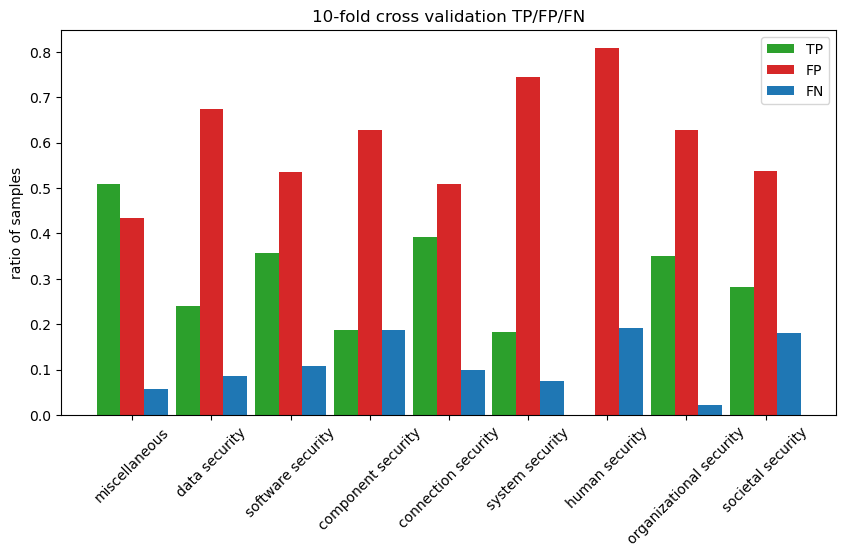

In [22]:
# same but normalized 
dataset = copy.deepcopy(trans.data)
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in dataset['labels']], axis=0)
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
counts = np.bincount(non_oh)
print(counts)

x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security"]
x = np.arange(len(x_labels))

width = 0.3 
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(x-width, TP/(TP+FP+FN), width,label='TP', color='tab:green')
ax.bar(x, FP/(TP+FP+FN), width, label= 'FP', color='tab:red')
ax.bar(x + width, FN/(TP+FP+FN), width, label='FN', color='tab:blue')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylabel('ratio of samples')
ax.set_title('10-fold cross validation TP/FP/FN')
ax.legend()

roc_auc:  [0.73719019 0.762762   0.85734266 0.72589286 0.81633065 0.71168526
 0.48161121 0.59909091 0.78673835]
f1:  0.5140913508260447
f1:  [0.673992673992674, 0.3861386138613861, 0.5263157894736842, 0.3137254901960784, 0.5638766519823789, 0.30833333333333335, 0.0, 0.51875, 0.44000000000000006, 0.5140913508260447]
[0.7371901913089212, 0.7627620044013131, 0.8573426573426572, 0.7258928571428571, 0.8163306451612903, 0.711685261303582, 0.4816112084063047, 0.5990909090909091, 0.7867383512544803, 0.8205596143049132]


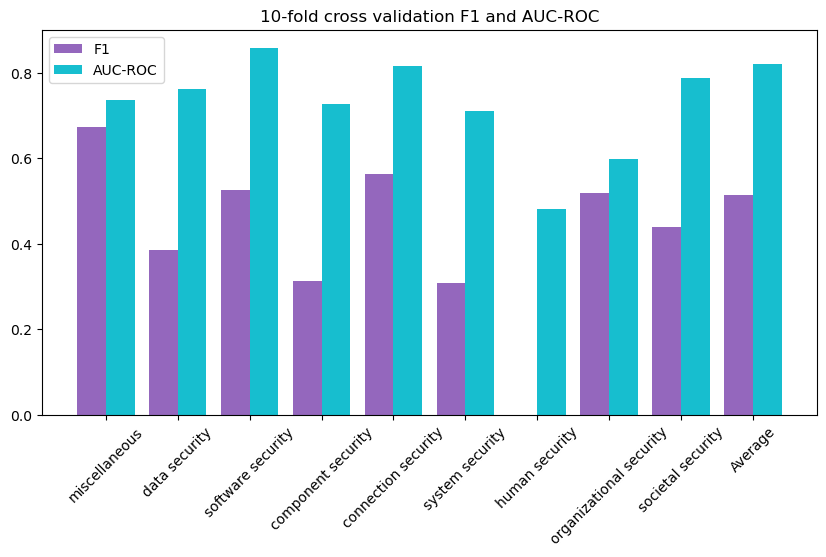

In [25]:
f1s = f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average=None)

x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security", "Average"]
x = np.arange(len(x_labels))

rocs = roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average=None,multi_class='ovr')
print('roc_auc: ',rocs)
#print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
 #                       average='macro')) # -> if all classes are equally important
print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average='micro')) # -> if all samples are equally important 
avg_f1 = f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average='micro')
f1s = [x for x in f1s]
f1s.append(avg_f1)
print('f1: ',f1s)
avg_roc = roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average='micro',multi_class='ovr')
rocs = [x for x in rocs]
rocs.append(avg_roc)
print(rocs)
width = 0.4
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(x-width/2, f1s, width,label='F1', color='tab:purple')
#ax.bar(x, FP, width, label= 'FP', color='r')
ax.bar(x + width/2, rocs, width, label='AUC-ROC', color='tab:cyan')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_title('10-fold cross validation F1 and AUC-ROC')
ax.legend()

### Old code 

In [ ]:
# when we use the 2017 KDs as a validation dataset only. 
def train2(self, training_args, data_aug=False, balance=False, synthetic=False): 
        fold_results = [] 
        self.dict1 = {}
        self.dict2 = {}
        fold = 0 

        print(f"Training on fold {fold + 1}")
        self.val_dataset = self.data
        self.val_dataset = self.val_dataset.remove_columns(['Statement Description', '0'])
        self.init_models(self.model_name)                    # we must re-initiate the classification model for every fold
        # this is where we would add the synthetic data
        if synthetic == True: 
            dataset = datasets.load_dataset("csv",data_files={"train": "data/train_CSEC2017.csv"}, split='train')
            dataset = dataset.remove_columns('Statement Description')
            dataset = dataset.remove_columns('label')
            dataset = dataset.remove_columns(['Unnamed: 0','Unnamed: 12'])
            dataset = dataset.map(preprocess_csec) 
            dataset = dataset.remove_columns(['topics'])
            self.train_dataset = copy.deepcopy(dataset)
            
            #print(dataset2)
            # merge train_dataset with synthetic dataset. 
            #self.train_dataset = concatenate_datasets([train_dataset, dataset])
            print(self.train_dataset)

        if data_aug == True: 
            #print('true')
            output = self.train_dataset.map(data_augmentation)
            self.train_dataset = copy.deepcopy(output)

        if balance == True: 
            self.train_dataset = balance_dataset(copy.deepcopy(self.train_dataset))
        
        self.trainer = Trainer(
        model=self.model,
        args=training_args,
        train_dataset=self.train_dataset,
        eval_dataset=self.val_dataset,
        tokenizer=self.tokenizer,
        data_collator=self.data_collator,
        compute_metrics=compute_metrics,)
      
        self.trainer.train()
        metrics = self.trainer.evaluate()
        print(f"Fold {fold+1} results_before: {metrics}")
        output = self.trainer.predict(self.val_dataset)
        self.dict1[fold] = copy.deepcopy(output[1])
        self.dict2[fold] = copy.deepcopy(output[0])
            
        predictions = sigmoid(output[0])
        predictions = (predictions > 0.5).astype(int) #.reshape(-1)
        self.conf_matrix = multilabel_confusion_matrix(output[1].astype(int), predictions)
        print('confusion matrix: ',self.conf_matrix)
        fold_results.append(metrics)
        print(f"Fold {fold+1} results: {metrics}")
            
        avg_metrics = {key: np.mean([fold[key] for fold in fold_results]) for key in fold_results[0]}
        print(f"Average metrics across all folds: {avg_metrics}")
        return avg_metrics

In [19]:
clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])
pr = evaluate.load('precision')
re = evaluate.load('recall')
f1 = evaluate.load('f1') 
acc = evaluate.load('accuracy')

print('precision: ',pr.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1)))
print('recall: ',re.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1)))
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1)))
print('acc: ',acc.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1)))

metrics2 = clf_metrics.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1))
print(metrics2)

precision:  {'precision': 0.628140703517588}
recall:  {'recall': 0.5942947702060222}
f1:  {'f1': 0.6107491856677525}
acc:  {'accuracy': 0.9077932098765432}
{'accuracy': 0.9077932098765432, 'f1': 0.6107491856677525, 'precision': 0.628140703517588, 'recall': 0.5942947702060222}


In [24]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score 
from transformers import EvalPrediction
import torch 
print('accuracy: ',accuracy_score(y_pred=predictions, y_true=labels.astype(int)))
print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average='micro'))
print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average='macro'))
print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average=None))
print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average='samples'))
print('roc_auc: ',roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average=None,multi_class='ovr'))
print('roc_auc: ',roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average='micro',multi_class='ovr')) # only implemented for ovr
print('roc_auc: ',roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average='macro',multi_class='ovo'))
print('roc_auc: ',roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average='macro',multi_class='ovr'))

accuracy:  0.08680555555555555
f1:  0.5140913508260447
f1:  0.4145702836488372
f1:  [0.67399267 0.38613861 0.52631579 0.31372549 0.56387665 0.30833333
 0.         0.51875    0.44      ]
f1:  0.5373759920634922
roc_auc:  [0.73719019 0.762762   0.85734266 0.72589286 0.81633065 0.71168526
 0.48161121 0.59909091 0.78673835]
roc_auc:  0.8205596143049132
roc_auc:  0.7198493428235906
roc_auc:  0.7198493428235906


In [49]:
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1),
                        average='micro'))
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1),
                        average='macro'))
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1),
                        average='weighted'))
#print('f1: ',f1.compute(predictions=predictions, references=labels.astype(int),
   #                     average='samples'))
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1),
                        average=None))

f1:  {'f1': 0.9068287037037037}
f1:  {'f1': 0.7792462337032589}
f1:  {'f1': 0.9062136144040314}
f1:  {'f1': array([0.94706849, 0.61142397])}
